In [5]:
# 导入所需模块
import os
import csv
import numpy as np
import mindspore as ms
from mindspore import nn, ops, dataset, Tensor
from mindspore.train import LossMonitor
from mindspore.ops import SigmoidCrossEntropyWithLogits
import matplotlib.pyplot as plt

# 设置为图模式，使用 CPU 运行
ms.set_context(mode=ms.GRAPH_MODE, device_target="CPU")

print("✅ 环境准备完成，当前设备:", ms.get_context("device_target"))



环境准备完成，当前设备: CPU


In [6]:
with open('iris.data') as csv_file:
    data = list(csv.reader(csv_file, delimiter=','))
print(data[40:60])  # 打印部分数据


[['5.0', '3.5', '1.3', '0.3', 'Iris-setosa'], ['4.5', '2.3', '1.3', '0.3', 'Iris-setosa'], ['4.4', '3.2', '1.3', '0.2', 'Iris-setosa'], ['5.0', '3.5', '1.6', '0.6', 'Iris-setosa'], ['5.1', '3.8', '1.9', '0.4', 'Iris-setosa'], ['4.8', '3.0', '1.4', '0.3', 'Iris-setosa'], ['5.1', '3.8', '1.6', '0.2', 'Iris-setosa'], ['4.6', '3.2', '1.4', '0.2', 'Iris-setosa'], ['5.3', '3.7', '1.5', '0.2', 'Iris-setosa'], ['5.0', '3.3', '1.4', '0.2', 'Iris-setosa'], ['7.0', '3.2', '4.7', '1.4', 'Iris-versicolor'], ['6.4', '3.2', '4.5', '1.5', 'Iris-versicolor'], ['6.9', '3.1', '4.9', '1.5', 'Iris-versicolor'], ['5.5', '2.3', '4.0', '1.3', 'Iris-versicolor'], ['6.5', '2.8', '4.6', '1.5', 'Iris-versicolor'], ['5.7', '2.8', '4.5', '1.3', 'Iris-versicolor'], ['6.3', '3.3', '4.7', '1.6', 'Iris-versicolor'], ['4.9', '2.4', '3.3', '1.0', 'Iris-versicolor'], ['6.6', '2.9', '4.6', '1.3', 'Iris-versicolor'], ['5.2', '2.7', '3.9', '1.4', 'Iris-versicolor']]


In [7]:
label_map = {'Iris-setosa': 0, 'Iris-versicolor': 1}
X = np.array([[float(x) for x in s[:-1]] for s in data[:100]], np.float32)
Y = np.array([[label_map[s[-1]]] for s in data[:100]], np.float32)


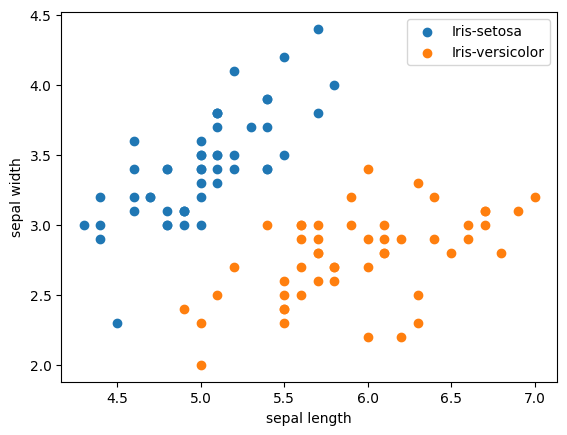

In [8]:
from matplotlib import pyplot as plt
# %matplotlib inline
plt.scatter(X[:50, 0], X[:50, 1], label='Iris-setosa')
plt.scatter(X[50:, 0], X[50:, 1], label='Iris-versicolor')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()
plt.show()


In [11]:
# 随机选择80个训练样本索引
np.random.seed(42)  # 固定随机种子以便复现
train_idx = np.random.choice(100, 80, replace=False)
test_idx = np.array(list(set(range(100)) - set(train_idx)))

# 构建训练集和测试集
X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print(" 训练集大小:", X_train.shape[0])
print(" 测试集大小:", X_test.shape[0])


 训练集大小: 80
 测试集大小: 20


In [12]:
# 将训练数据打包成元组列表
XY_train = list(zip(X_train, Y_train))

# 创建数据集对象，并进行打乱和批处理
ds_train = dataset.GeneratorDataset(XY_train, ['x', 'y'], shuffle=True)
ds_train = ds_train.shuffle(buffer_size=80).batch(32, drop_remainder=True)

print("📦 训练数据集 batch 数:", ds_train.get_dataset_size())


📦 训练数据集 batch 数: 2


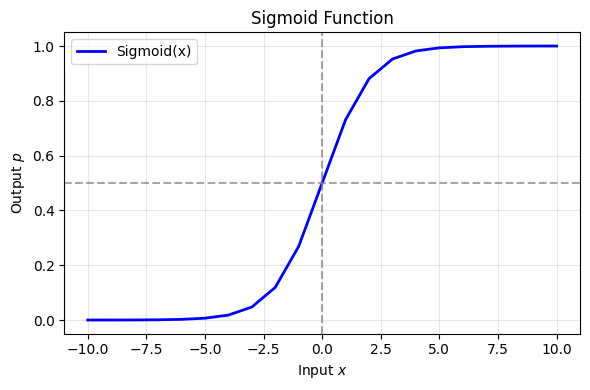

In [13]:
# 生成输入值
coor_x = np.arange(-10, 11, dtype=np.float32)
coor_y = nn.Sigmoid()(Tensor(coor_x)).asnumpy()

# 绘图
plt.figure(figsize=(6, 4))
plt.plot(coor_x, coor_y, 'b-', linewidth=2, label='Sigmoid(x)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.xlabel('Input $x$')
plt.ylabel('Output $p$')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# 自定义损失函数类（封装 Sigmoid + CrossEntropy）
class Loss(nn.Cell):
    def __init__(self):
        super(Loss, self).__init__()
        self.loss_fn = SigmoidCrossEntropyWithLogits()
        self.reduce_mean = ops.ReduceMean(keep_dims=False)

    def construct(self, logits, labels):
        per_sample_loss = self.loss_fn(logits, labels)
        return self.reduce_mean(per_sample_loss, -1)

# 定义网络：单层全连接（逻辑回归）
net = nn.Dense(4, 1)

# 定义损失函数和优化器
loss_fn = Loss()
optimizer = nn.optim.SGD(net.trainable_params(), learning_rate=0.003)

print("模型结构:")
print(net)


模型结构:
Dense<input_channels=4, output_channels=1, has_bias=True>


In [ ]:
# 使用高层API封装模型
model = ms.train.Model(network=net, loss_fn=loss_fn, optimizer=optimizer)

# 开始训练
print("🔥 开始训练...")
model.train(
    epoch=10,
    train_dataset=ds_train,
    callbacks=[LossMonitor(per_print_times=ds_train.get_dataset_size())],
    dataset_sink_mode=False  # CPU模式下设为False
)
print("✅ 训练完成")



In [ ]:
# 在测试集上预测
logits = model.predict(Tensor(X_test))  # 输出是 logit 值
probs = 1 / (1 + np.exp(-logits.asnumpy()))  # 手动应用 sigmoid 得到概率
preds = np.round(probs)  # 四舍五入得到类别 0 或 1

# 计算准确率
accuracy = np.mean(preds == Y_test)
print(f"📈 测试集准确率: {accuracy:.4f}")


测试集准确率: 1.0000
